In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/carrie1/ecommerce-data/data.csv


In [2]:
import pandas as pd
import duckdb

df = pd.read_csv('/kaggle/input/datasets/carrie1/ecommerce-data/data.csv', encoding='ISO-8859-1')
duckdb.register('retail', df)

duckdb.sql("SELECT * FROM retail LIMIT 5")


┌───────────┬───────────┬─────────────────────────────────────┬──────────┬────────────────┬───────────┬────────────┬────────────────┐
│ InvoiceNo │ StockCode │             Description             │ Quantity │  InvoiceDate   │ UnitPrice │ CustomerID │    Country     │
│  varchar  │  varchar  │               varchar               │  int64   │    varchar     │  double   │   double   │    varchar     │
├───────────┼───────────┼─────────────────────────────────────┼──────────┼────────────────┼───────────┼────────────┼────────────────┤
│ 536365    │ 85123A    │ WHITE HANGING HEART T-LIGHT HOLDER  │        6 │ 12/1/2010 8:26 │      2.55 │    17850.0 │ United Kingdom │
│ 536365    │ 71053     │ WHITE METAL LANTERN                 │        6 │ 12/1/2010 8:26 │      3.39 │    17850.0 │ United Kingdom │
│ 536365    │ 84406B    │ CREAM CUPID HEARTS COAT HANGER      │        8 │ 12/1/2010 8:26 │      2.75 │    17850.0 │ United Kingdom │
│ 536365    │ 84029G    │ KNITTED UNION FLAG HOT WATER BOTTLE 

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
df.isnull().sum()


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
duckdb.sql("SELECT COUNT(*) FROM retail")


┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│       541909 │
└──────────────┘

In [7]:
duckdb.sql("SELECT * FROM retail LIMIT 10")


┌───────────┬───────────┬─────────────────────────────────────┬──────────┬────────────────┬───────────┬────────────┬────────────────┐
│ InvoiceNo │ StockCode │             Description             │ Quantity │  InvoiceDate   │ UnitPrice │ CustomerID │    Country     │
│  varchar  │  varchar  │               varchar               │  int64   │    varchar     │  double   │   double   │    varchar     │
├───────────┼───────────┼─────────────────────────────────────┼──────────┼────────────────┼───────────┼────────────┼────────────────┤
│ 536365    │ 85123A    │ WHITE HANGING HEART T-LIGHT HOLDER  │        6 │ 12/1/2010 8:26 │      2.55 │    17850.0 │ United Kingdom │
│ 536365    │ 71053     │ WHITE METAL LANTERN                 │        6 │ 12/1/2010 8:26 │      3.39 │    17850.0 │ United Kingdom │
│ 536365    │ 84406B    │ CREAM CUPID HEARTS COAT HANGER      │        8 │ 12/1/2010 8:26 │      2.75 │    17850.0 │ United Kingdom │
│ 536365    │ 84029G    │ KNITTED UNION FLAG HOT WATER BOTTLE 

In [8]:
df = df.dropna(subset=['CustomerID'])


In [9]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]


In [10]:
=df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


SyntaxError: invalid syntax (4233099659.py, line 1)

In [ ]:
=df['TotalPrice'] = df['Quantity'] * df['UnitPrice']


In [ ]:
=df.columns


In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


In [ ]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']


In [ ]:
df['InvoiceDate'].dtype


In [ ]:
df.head()


In [ ]:
df.columns


In [ ]:
df['InvoiceDate'].dtype


In [ ]:
=duckdb.sql("""
SELECT Description, SUM(TotalPrice) AS Revenue
FROM retail
GROUP BY Description
ORDER BY Revenue DESC
LIMIT 10
""")


In [ ]:
duckdb.sql("SELECT Description, SUM(TotalPrice) AS Revenue FROM retail GROUP BY Description ORDER BY Revenue DESC LIMIT 10")


In [ ]:
=duckdb.sql("SELECT * FROM retail LIMIT 5")


In [ ]:
import duckdb
duckdb.register('retail', df)


In [ ]:
duckdb.sql("SELECT Country, COUNT(DISTINCT InvoiceNo) AS Orders FROM retail GROUP BY Country ORDER BY Orders DESC")


In [ ]:
=duckdb.sql("SELECT DATE_TRUNC('month', InvoiceDate) AS Month, SUM(TotalPrice) AS Revenue FROM retail GROUP BY Month ORDER BY Month")


In [ ]:
=duckdb.sql("SELECT CustomerID, SUM(TotalPrice) AS Revenue FROM retail GROUP BY CustomerID ORDER BY Revenue DESC LIMIT 10")


In [ ]:
=duckdb.sql("SELECT Description, SUM(Quantity) AS TotalQty FROM retail GROUP BY Description ORDER BY TotalQty DESC LIMIT 10")


In [ ]:
duckdb.sql("SELECT Description, SUM(Quantity) AS ReturnedQty FROM retail WHERE Quantity < 0 GROUP BY Description ORDER BY ReturnedQty ASC LIMIT 10")


In [ ]:
duckdb.sql("SELECT DATE_TRUNC('month', InvoiceDate) AS Month, COUNT(DISTINCT CustomerID) AS UniqueCustomers FROM retail GROUP BY Month ORDER BY Month")


In [ ]:
duckdb.sql("SELECT DATE_TRUNC('month', InvoiceDate) AS Month, SUM(TotalPrice) AS Revenue FROM retail GROUP BY Month ORDER BY Month")


In [ ]:
duckdb.sql("SELECT CustomerID, SUM(TotalPrice) AS Revenue FROM retail GROUP BY CustomerID ORDER BY Revenue DESC LIMIT 10")


In [ ]:
duckdb.sql("SELECT Description, SUM(Quantity) AS TotalQty FROM retail GROUP BY Description ORDER BY TotalQty DESC LIMIT 10")


In [ ]:
import datetime as dt

snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()


In [ ]:
rfm['R'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F'] = pd.qcut(rfm['Frequency'], 4, labels=[1,2,3,4])
rfm['M'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = (
    rfm['R'].astype(str) +
    rfm['F'].astype(str) +
    rfm['M'].astype(str)
)

rfm.head()


In [ ]:
rfm['R_rank'] = rfm['Recency'].rank(method='first')
rfm['F_rank'] = rfm['Frequency'].rank(method='first')
rfm['M_rank'] = rfm['Monetary'].rank(method='first')

rfm['R'] = pd.qcut(rfm['R_rank'], 4, labels=[4,3,2,1])
rfm['F'] = pd.qcut(rfm['F_rank'], 4, labels=[1,2,3,4])
rfm['M'] = pd.qcut(rfm['M_rank'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = (
    rfm['R'].astype(str) +
    rfm['F'].astype(str) +
    rfm['M'].astype(str)
)

rfm.head()


In [ ]:
def segment(row):
    score = row['RFM_Score']

    if score in ['444','443','434','433','344']:
        return 'Champions'
    elif score in ['333','332','323','324','234','233']:
        return 'Loyal Customers'
    elif score in ['144','143','134','133','244','243']:
        return 'Potential Loyalists'
    elif score in ['412','411','421','422','312','311']:
        return 'Recent Customers'
    elif score in ['211','212','221','222','231']:
        return 'At Risk'
    elif score in ['111','112','121','122']:
        return 'Hibernating'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment, axis=1)
rfm.head()


In [ ]:
=rfm['Segment'].value_counts()


In [ ]:
rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)


In [ ]:
rfm['Segment'].value_counts()


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
rfm['Segment'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


In [ ]:
# Örnek: ana veri seti
df.head()


In [28]:
import pandas as pd

df = pd.read_csv('OnlineRetail.csv')  # sen ne kullandıysan onu


FileNotFoundError: [Errno 2] No such file or directory: 'OnlineRetail.csv'

In [18]:
import pandas as pd
import datetime as dt

# 1) InvoiceDate'i datetime yap
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 2) TotalPrice oluştur
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# 3) CustomerID boş olmayanları al
df_clean = df.dropna(subset=['CustomerID'])

# 4) Snapshot date
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# 5) RFM hesapla
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'TotalPrice': 'sum'                                       # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

# 6) Segment eklemek için basit bir sınıflandırma
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

def segment_map(score):
    if score.startswith('4'):
        return 'Champions'
    elif score.startswith('3'):
        return 'Loyal Customers'
    elif score.startswith('2'):
        return 'Potential Loyalists'
    else:
        return 'At Risk'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_map)


In [19]:
rfm.head()


,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,At Risk
12347.0,2,7,4310.00,4,4,4,444,Champions
12348.0,75,4,1797.24,2,3,4,234,Potential Loyalists
12349.0,19,1,1757.55,3,1,4,314,Loyal Customers
12350.0,310,1,334.40,1,1,2,112,At Risk


In [ ]:
=import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
rfm['Segment'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


/tmp/ipykernel_164/3884051445.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.resample('M', on='InvoiceDate')['TotalPrice'].sum()


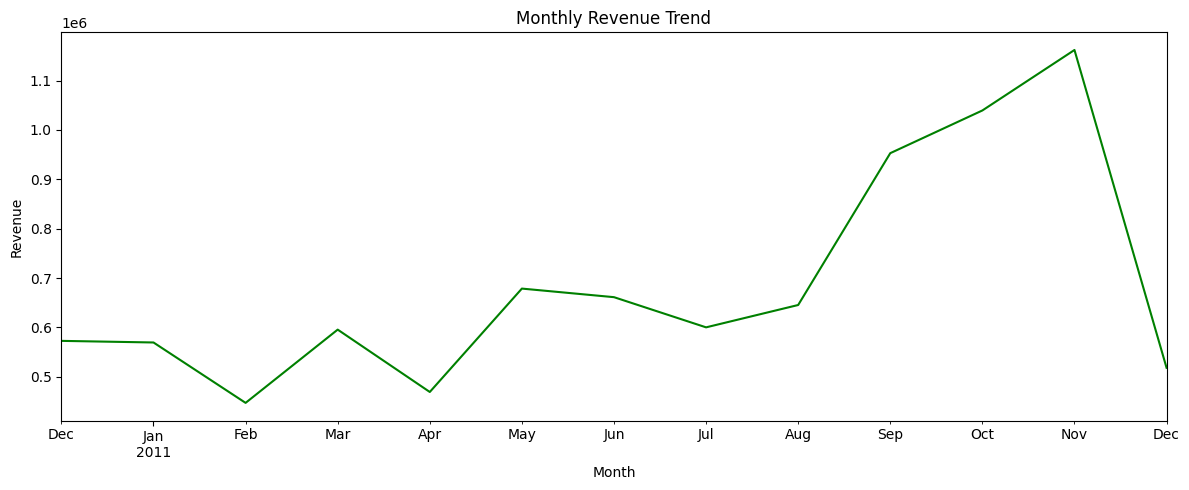

In [20]:
monthly = df.resample('M', on='InvoiceDate')['TotalPrice'].sum()

plt.figure(figsize=(12,5))
monthly.plot(color='green')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()


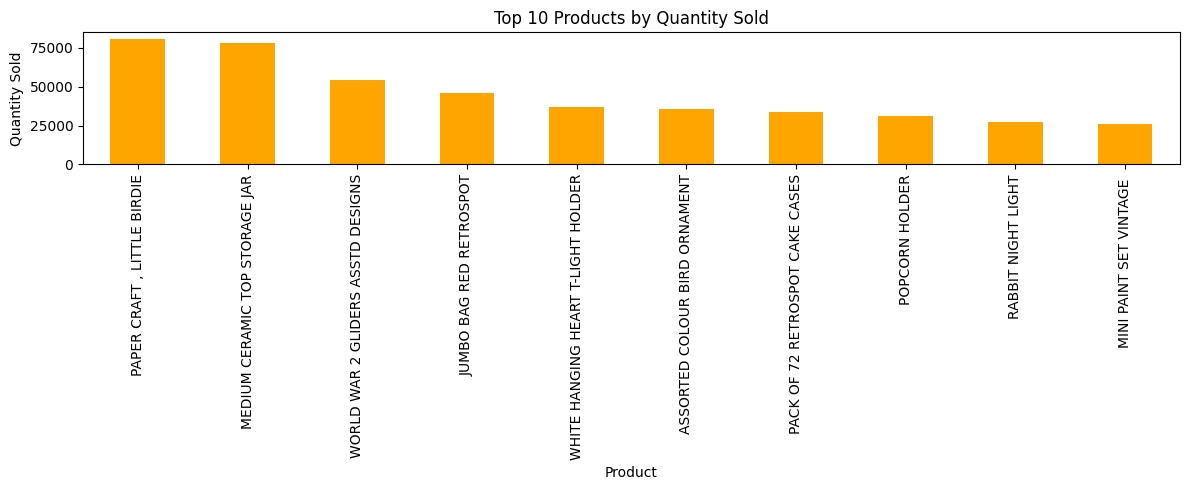

In [29]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
top_products.plot(kind='bar', color='orange')
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.tight_layout()
plt.show()


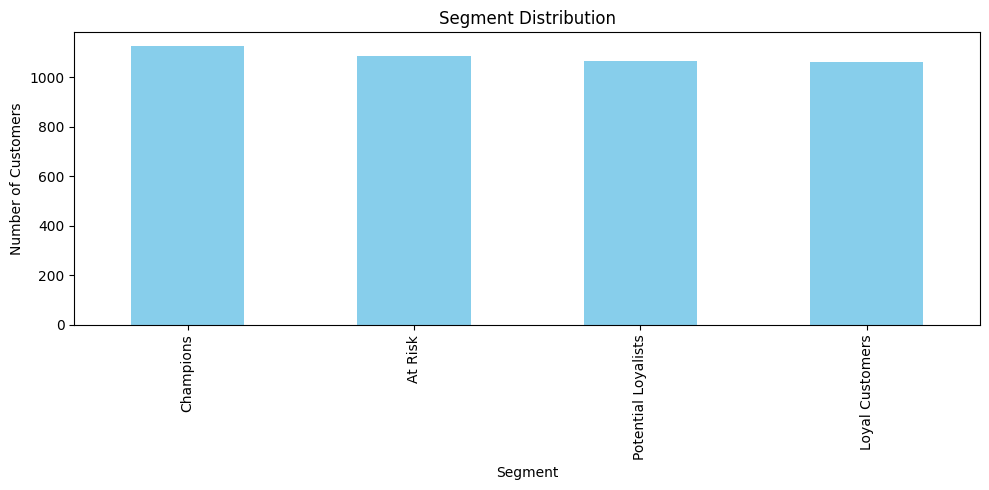

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
rfm['Segment'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


In [21]:
rfm.head()


,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,At Risk
12347.0,2,7,4310.00,4,4,4,444,Champions
12348.0,75,4,1797.24,2,3,4,234,Potential Loyalists
12349.0,19,1,1757.55,3,1,4,314,Loyal Customers
12350.0,310,1,334.40,1,1,2,112,At Risk


In [22]:
rfm.head()


,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,At Risk
12347.0,2,7,4310.00,4,4,4,444,Champions
12348.0,75,4,1797.24,2,3,4,234,Potential Loyalists
12349.0,19,1,1757.55,3,1,4,314,Loyal Customers
12350.0,310,1,334.40,1,1,2,112,At Risk


In [13]:
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


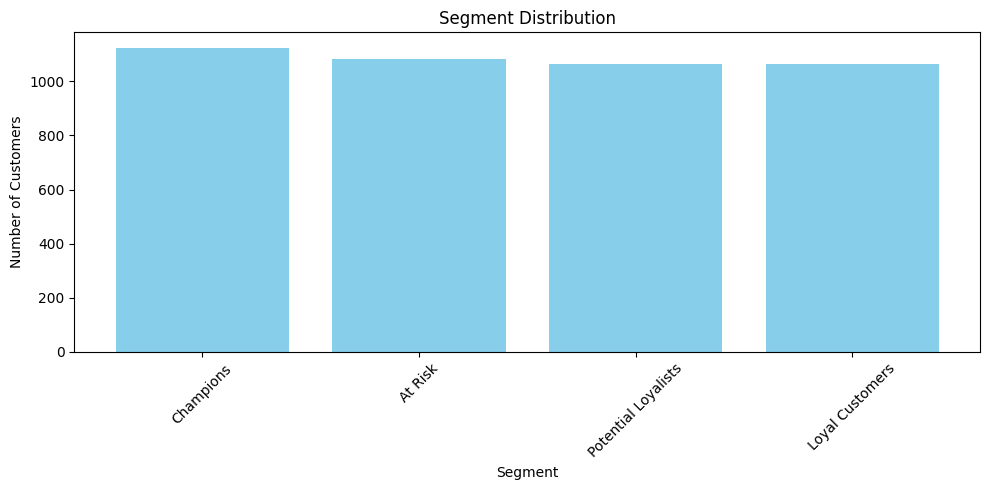

In [23]:
import matplotlib.pyplot as plt

seg_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(10,5))
plt.bar(seg_counts.index, seg_counts.values, color='skyblue')
plt.title('Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


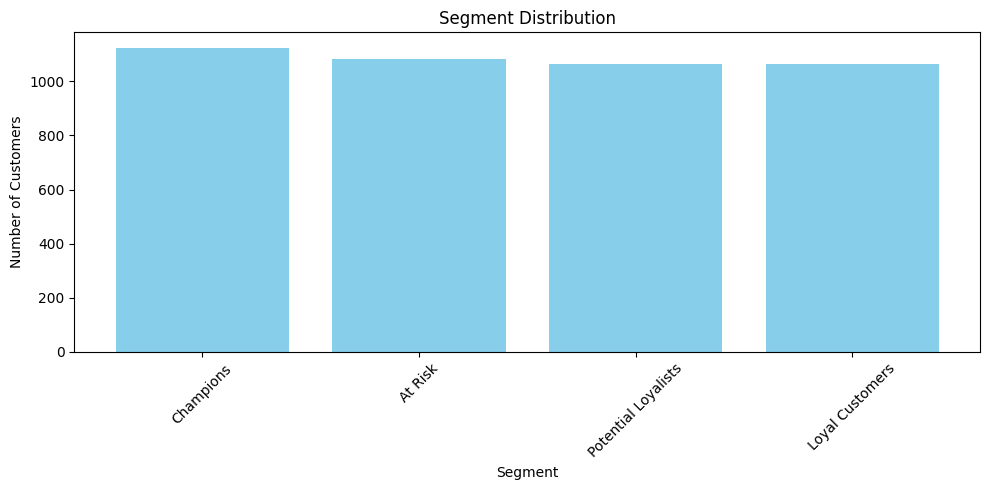

In [24]:
import matplotlib.pyplot as plt

seg_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(10,5))
plt.bar(seg_counts.index, seg_counts.values, color='skyblue')
plt.title('Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
